<a href="https://colab.research.google.com/github/Mugetsu-Nuckie/dzstatprac/blob/main/dz3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Serial test

Idea: break the sequence $x_1, x_2, x_3, ..., x_{2n}$ into consecutive series of length $2$: $(x_1, x_2), (x_3, x_4), ..., (x_{2n-1}, x_{2n})$ and look at each element as a random and independent point in $2D$ space. Next, apply chi-square. Similarly, one can construct series of length $3, 4$, etc.

### Problem 1
Implement serial test and apply to a `samples`

In [ ]:
import numpy as np
from scipy import stats
from collections import Counter
def rng(m=2**32, a=1103515245, c=12345):
    rng.current = (a * rng.current + c) % m
    return rng.current / m


rng.current = 1
samples = [rng() for _ in range(1000)]
def serial_test(samples, d=2, num_bins=10):
    samples = np.array(samples)
    n = len(samples) // d
    samples = samples[:n * d]
    series = samples.reshape(n, d)
    binned = np.zeros_like(series, dtype=int)
    for i in range(d):
        binned[:, i] = np.digitize(series[:, i],
                            np.linspace(0, 1, num_bins + 1)[1:-1])
    combinations = [tuple(row) for row in binned]
    observed_counts = Counter(combinations)
    total_combinations = num_bins ** d
    expected = n / total_combinations
    chi2_stat = 0
    for count in observed_counts.values():
        chi2_stat += (count - expected) ** 2 / expected
    df = total_combinations - 1
    p_value = 1 - stats.chi2.cdf(chi2_stat, df)
    return chi2_stat, p_value
if __name__ == "__main__":
    chi2, p_val = serial_test(samples, d=2, num_bins=10)
    print("Serial Test")
    print(f"p-значение: {p_val:.4f}")
    print(f"Результат: {'H0 не отвергаем' if p_val > 0.05 else 'отвергаем H0'}")



Serial Test
p-значение: 0.4698
Результат: H0 не отвергаем


### Permutation test

We again decompose the sequence $x_1, x_2, x_3, ..., x_{dn}$ into consecutive series of length $d$: $(x_1, ..., x_d), (x_{d+1}, x_{2d+d}), \ldots, (x_{nd-d+1}, x_{nd})$. A series of $d$ elements can be ordered in $d!$ ways and each way of ordering is equally probable. Hence the idea of the test is to count how many times each ordering occurs among $n$ series and apply the $\chi^2$ test.

### Problem 2*
Implement permutation test and apply to a `samples`

In [ ]:
import numpy as np
from scipy import stats
from collections import Counter
from itertools import permutations
def permutation_test(samples, d=3):
    samples = np.array(samples)
    n = len(samples) // d
    samples = samples[:n * d]
    series = samples.reshape(n, d)
    permutation_counts = Counter()
    for series_row in series:
        ranks = np.argsort(np.argsort(series_row))
        permutation_counts[tuple(ranks)] += 1
    all_permutations = list(permutations(range(d)))
    num_permutations = len(all_permutations)
    expected = n / num_permutations
    chi2_stat = 0
    for perm in all_permutations:
        observed = permutation_counts.get(perm, 0)
        chi2_stat += (observed - expected) ** 2 / expected
    df = num_permutations - 1
    p_value = 1 - stats.chi2.cdf(chi2_stat, df)
    return chi2_stat, p_value
if __name__ == "__main__":
    chi2, p_val = permutation_test(samples, d=3)
    print("Permutation Test")
    print(f"p-значение: {p_val:.4f}")
    print(f"Результат: {'H0 не отвергаем' if p_val > 0.05 else 'отвергаем H0'}")

Permutation Test
p-значение: 0.4337
Результат: H0 не отвергаем


### Problem 3

Provide a statistical test to show that `rng_bad` has problems but `rng_good` does not.

rng_bad chi2, p: (np.float64(8085.22), np.float64(0.0))
rng_good chi2, p: (np.float64(3.8999999999999995), np.float64(0.9178700411914169))


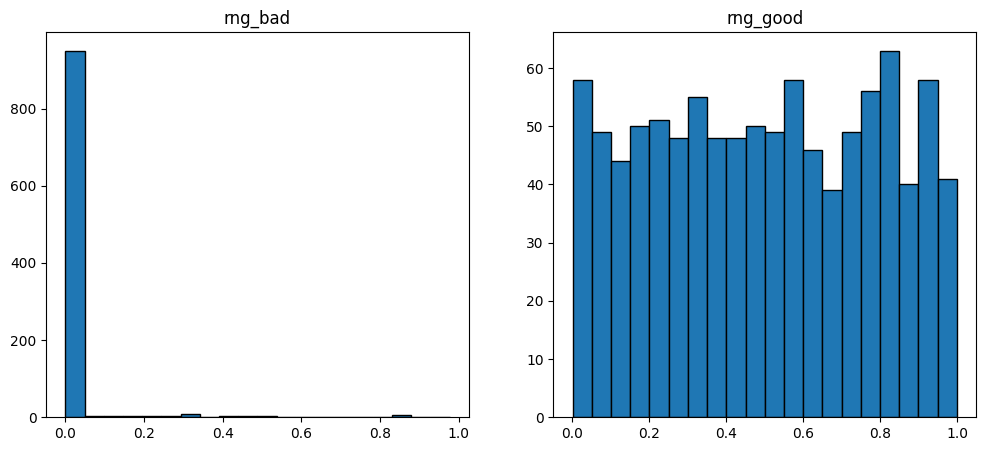

In [ ]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

def rng_bad(seed=1234, n=1000):
    x = seed
    res = []
    for _ in range(n):
        x = (x ** 2) // 100 % 10000
        res.append(x / 10000)
    return np.array(res)

def rng_good(n=1000):
    return np.random.rand(n)

def chi_square_test(data, bins=10):
    obs, edges = np.histogram(data, bins=bins, range=(0, 1))
    exp = len(data) / bins
    chi2 = np.sum((obs - exp) ** 2 / exp)
    p_val = 1 - stats.chi2.cdf(chi2, bins - 1)
    return chi2, p_val

data_bad = rng_bad()
data_good = rng_good()

print("rng_bad chi2, p:", chi_square_test(data_bad))
print("rng_good chi2, p:", chi_square_test(data_good))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(data_bad, bins=20, edgecolor='black')
plt.title("rng_bad")
plt.subplot(1, 2, 2)
plt.hist(data_good, bins=20, edgecolor='black')
plt.title("rng_good")
plt.show()

* More randomness tests - [Diehard tests](https://en.wikipedia.org/wiki/Diehard_tests).
* More methods for generating a uniform value [here](https://en.wikipedia.org/wiki/List_of_random_number_generators).
* A story about dynamical systems and the transition to chaos https://www.youtube.com/watch?v=ovJcsL7vyrk&feature=youtu.be

### Problem 4
Simulate a sample of 1000 from a discrete distribution on a set of digits $0, 1, 2, \ldots, 9$ with weights $0.12, 0.3, 0.167, 0.24, 0.31, 0.54, 0.111, 0.02, 0.001, 0.2$. Construct a histogram from the sample. Optimise the algorithm by ordering the weights.

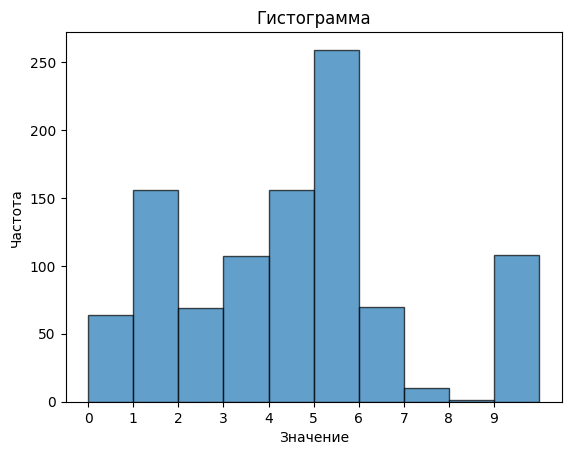

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

weights = np.array([0.12, 0.3, 0.167, 0.24, 0.31, 0.54, 0.111, 0.02, 0.001, 0.2])
weights = weights / np.sum(weights)
digits = np.arange(10)

sorted_idx = np.argsort(weights)[::-1]
weights_sorted = weights[sorted_idx]
digits_sorted = digits[sorted_idx]
cum_weights = np.cumsum(weights_sorted)

n_samples = 1000
u = np.random.rand(n_samples)
samples = np.zeros(n_samples, dtype=int)

for i in range(n_samples):
    for j in range(len(cum_weights)):
        if u[i] <= cum_weights[j]:
            samples[i] = digits_sorted[j]
            break

plt.hist(samples, bins=10, range=(0, 10), edgecolor='black', alpha=0.7)
plt.xticks(digits)
plt.xlabel("Значение")
plt.ylabel("Частота")
plt.title("Гистограмма")
plt.show()

### Problem 5
Simulate a sample of size 1000 from the distribution $\operatorname{Exp}(\lambda)$ using the Inverse transform method. Construct a sample histogram and an accurate plot of the distribution density.

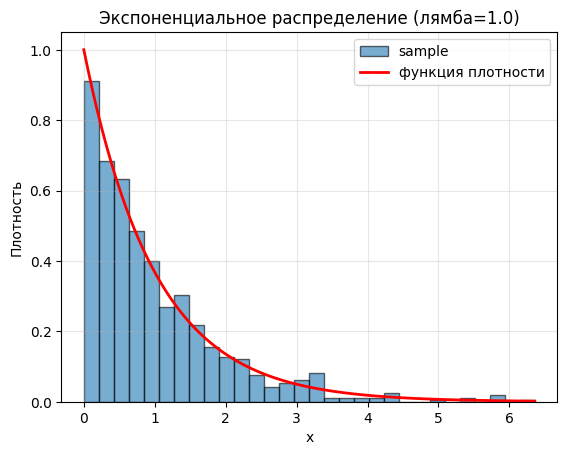

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

lam = 1.0
n_samples = 1000

u = np.random.rand(n_samples)
samples = -np.log(u) / lam

plt.hist(samples, bins=30, density=True, edgecolor='black', alpha=0.6, label="выборка")
x = np.linspace(0, np.max(samples), 100)
plt.plot(x, lam * np.exp(-lam * x), 'r', linewidth=2, label="функция плотности")
plt.xlabel("x")
plt.ylabel("Плотность")
plt.title(f"Экспоненциальное распределение (лямба={lam})")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Problem 6
Justify (orally) that the accept-reject method really samples from the required distribution. Simulate $1000$ points from the distribution with density $$e^xcos^2x \cdot \mathbb{I}_{[-\frac\pi2, \frac\pi2]}$$. Plot the sampled histogram on the sample and compare it with the plot of the exact density function.

/tmp/ipykernel_847/2934901693.py:25: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  density_normalized = density / np.trapz(density, x)


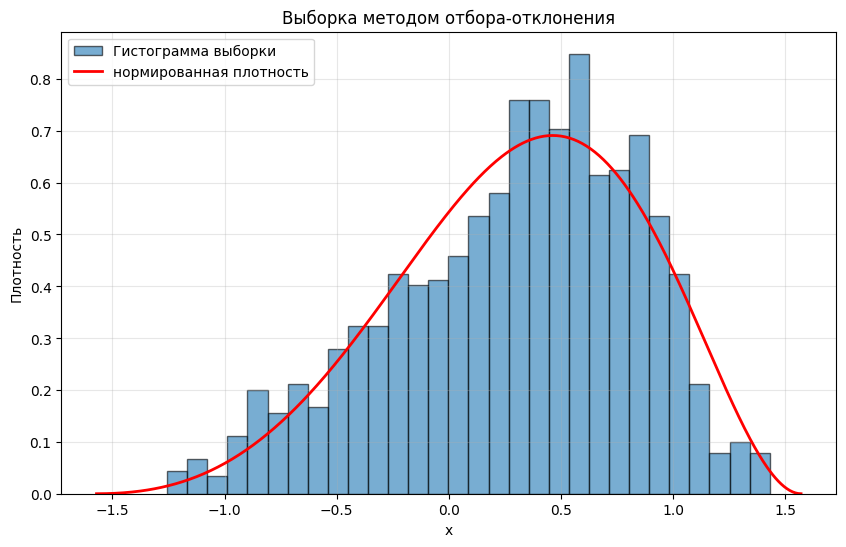

Коэффициент принятия: 0.4668
Теоретический коэффициент принятия: 0.2503


In [2]:
import numpy as np
import matplotlib.pyplot as plt
def f(x):
    return np.exp(x) * np.cos(x)**2
def sample_g(n):
    return np.random.uniform(-np.pi/2, np.pi/2, n)
x_grid = np.linspace(-np.pi/2, np.pi/2, 1000)
f_max = np.max(f(x_grid))
M = f_max * np.pi
def accept_reject(n_samples):
    samples = []
    while len(samples) < n_samples:
        x = sample_g(1)[0]
        u = np.random.uniform(0, 1)
        if u <= f(x) / (M / np.pi):
            samples.append(x)
    return np.array(samples)
np.random.seed(42)
samples = accept_reject(1000)
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(samples, bins=30, density=True, alpha=0.6,
        edgecolor='black', label='Гистограмма выборки')
x = np.linspace(-np.pi/2, np.pi/2, 500)
density = f(x)
density_normalized = density / np.trapz(density, x)
ax.plot(x, density_normalized, 'r-', linewidth=2,
        label='нормированная плотность')
ax.set_xlabel('x')
ax.set_ylabel('Плотность')
ax.set_title('Выборка методом отбора-отклонения')
ax.legend()
ax.grid(alpha=0.3)
plt.show()
n_total = 10000
n_accepted = 0
for _ in range(n_total):
    x = sample_g(1)[0]
    u = np.random.uniform(0, 1)
    if u <= f(x) / (M / np.pi):
        n_accepted += 1
print(f"Коэффициент принятия: {n_accepted / n_total:.4f}")
print(f"Теоретический коэффициент принятия: {1 / M:.4f}")

In [ ]:
# Your code here

### Problem 7
Model and depict a sample of 500 points uniformly distributed within a given triangle without using a selection method.

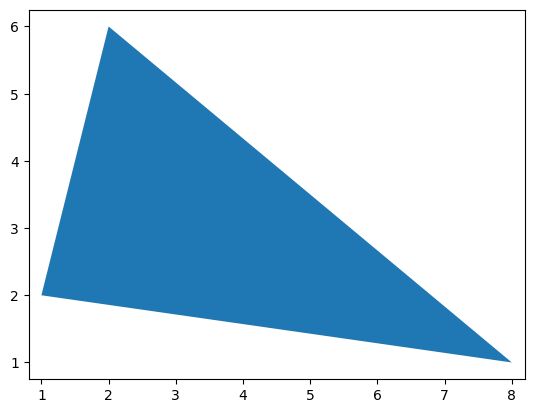

In [ ]:
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

fig = plt.figure()

polygon = Polygon(xy=np.array([[1, 2], [2, 6], [8, 1]]), closed=True)
plt.gca().add_collection(PatchCollection([polygon]))
plt.axis('equal')
plt.show()

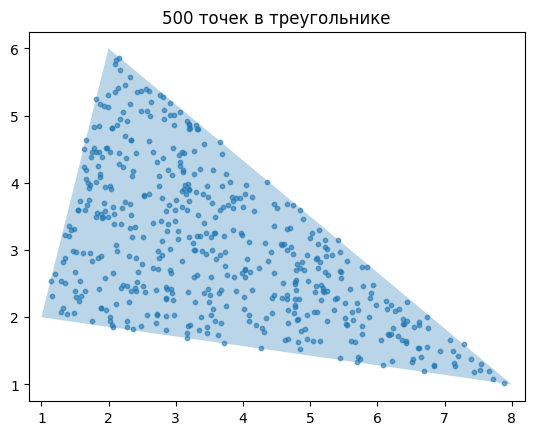

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
A = np.array([1, 2])
B = np.array([2, 6])
C = np.array([8, 1])
n_points = 500
r1 = np.random.uniform(0, 1, n_points)
r2 = np.random.uniform(0, 1, n_points)
sqrt_r1 = np.sqrt(r1).reshape(-1, 1)
r2 = r2.reshape(-1, 1)
points = (1 - sqrt_r1) * A + sqrt_r1 * (1 - r2) * B + sqrt_r1 * r2 * C
fig = plt.figure()
polygon = Polygon(xy=np.array([A, B, C]), closed=True)
plt.gca().add_collection(PatchCollection([polygon], alpha=0.3))
plt.scatter(points[:, 0], points[:, 1], s=10, alpha=0.6)
plt.axis('equal')
plt.title('500 точек в треугольнике')
plt.show()

### Problem 8
Model without using the selection method a sample of $500$ points uniformly distributed inside the unit circle. Picture the obtained points. Do they really fill the circle uniformly?

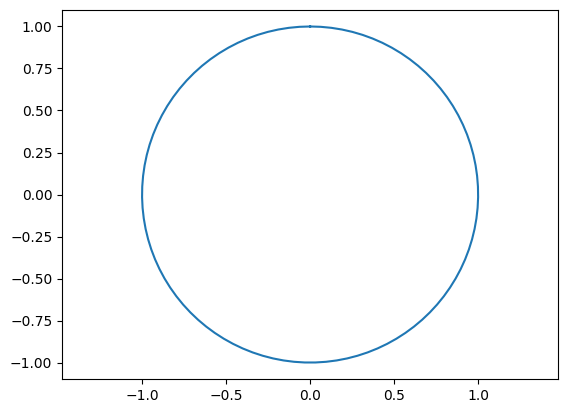

In [ ]:
fig = plt.figure()

t = np.linspace(0, 2*np.pi, 100)
plt.plot(np.sin(t), np.cos(t))
plt.axis('equal')
plt.show()

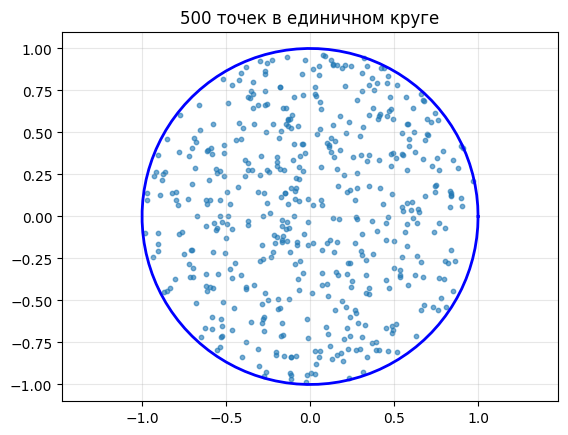

Проверка равномерности распределения:
Среднее расстояние от центра: 0.6496
Теоретическое среднее (2/3): 0.6667


In [6]:
import numpy as np
import matplotlib.pyplot as plt
n_points = 500
r = np.sqrt(np.random.uniform(0, 1, n_points))
theta = np.random.uniform(0, 2 * np.pi, n_points)
x = r * np.cos(theta)
y = r * np.sin(theta)
fig = plt.figure()
t = np.linspace(0, 2 * np.pi, 100)
plt.plot(np.cos(t), np.sin(t), 'b-', linewidth=2)
plt.scatter(x, y, s=10, alpha=0.6)
plt.axis('equal')
plt.title('500 точек в единичном круге')
plt.grid(alpha=0.3)
plt.show()
print("Проверка равномерности распределения:")
print(f"Среднее расстояние от центра: {np.mean(np.sqrt(x**2 + y**2)):.4f}")
print(f"Теоретическое среднее (2/3): {2/3:.4f}")

# Random normal generator

### Problem 9
Prove (orally) that the following algorithm (**Box-Muller algorithm**, https://en.wikipedia.org/wiki/Box%E2%80%93Muller_transform) generates a sample of independent $\mathcal{N}(0,1)$ random variables. Modify the method to exclude calls of trigonometric functions `np.sin` and `np.cos`. Using the modified method, simulate a sample size of $1000$ from a $2D$ Gaussian distribution with mean $\mu$ and covariance matrix $\Sigma$, where
$$\mu = \begin{pmatrix} 4 \\ 7 \end{pmatrix}^T, \quad \Sigma = \begin{pmatrix} 20 & -4 \\ -4 & 40 \end{pmatrix}.$$
Construct a 2D histogram of the resulting distribution. Compare the sample mean and covariance matrix with the exact values.

In [ ]:
import seaborn as sns

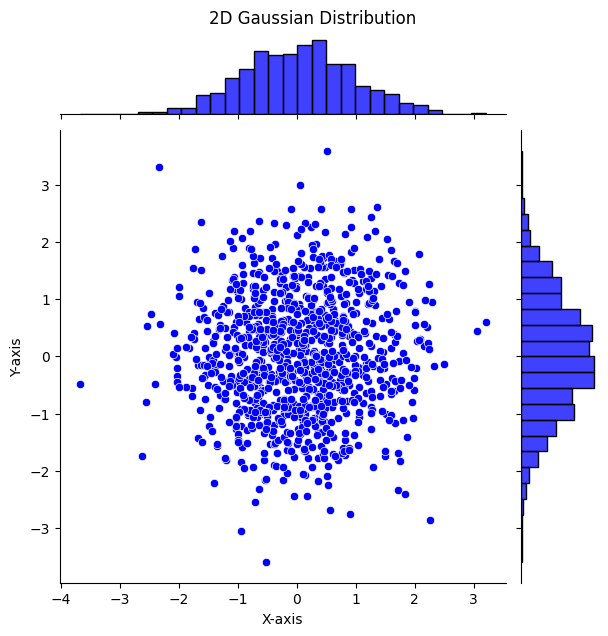

In [ ]:
n = 1000
u1, u2 = np.random.rand(2, n)
r = np.sqrt(-2 * np.log(u1))
theta = 2 * np.pi * u2
x = r * np.cos(theta)
y = r * np.sin(theta)


joint_plot = sns.jointplot(x=x, y=y, color="blue")
joint_plot.set_axis_labels('X-axis', 'Y-axis')
plt.suptitle('2D Gaussian Distribution', y=1.02)
plt.show()

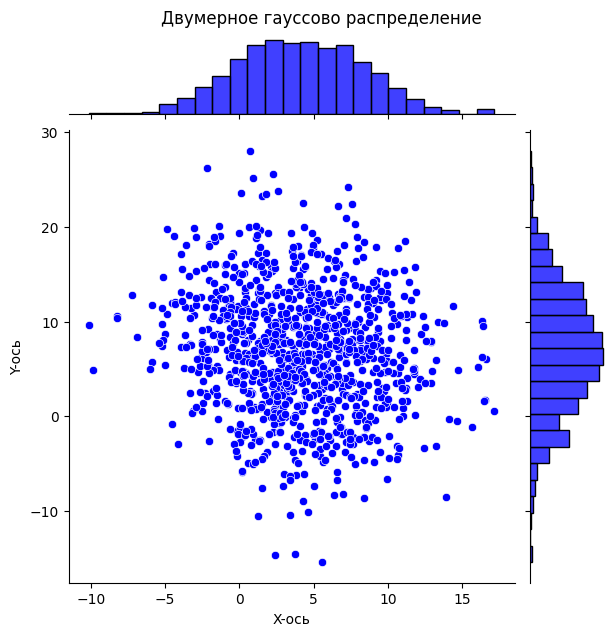

среднее значение: [4 7]
среднее значение выборки: [4.08691171 6.92069179]
Точная ковариация:
 [[20 -4]
 [-4 40]]
Выборочная ковариация:
 [[18.94610756 -3.82532764]
 [-3.82532764 41.67931189]]


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def mars(n):
    z0 = []
    z1 = []
    while len(z0) < n:
        m = n - len(z0)
        u = np.random.uniform(-1, 1, m)
        v = np.random.uniform(-1, 1, m)
        s = u**2 + v**2
        mask = (s > 0) & (s < 1)
        u_acc = u[mask]
        v_acc = v[mask]
        s_acc = s[mask]
        mul = np.sqrt(-2.0 * np.log(s_acc) / s_acc)
        z0.extend(u_acc * mul)
        z1.extend(v_acc * mul)
    return np.array(z0[:n]), np.array(z1[:n])

n = 1000
mu = np.array([4, 7])
Sigma = np.array([[20, -4], [-4, 40]])

z1, z2 = mars(n)
Z = np.vstack((z1, z2))

L = np.linalg.cholesky(Sigma)
X = mu.reshape(2, 1) + L @ Z
X = X.T

joint_plot = sns.jointplot(x=X[:, 0], y=X[:, 1], color="blue")
joint_plot.set_axis_labels('X-ось', 'Y-ось')
plt.suptitle('Двумерное гауссово распределение', y=1.02)
plt.show()

sample_mean = np.mean(X, axis=0)
sample_cov = np.cov(X, rowvar=False)

print("среднее значение:", mu)
print("среднее значение выборки:", sample_mean)
print("Точная ковариация:\n", Sigma)
print("Выборочная ковариация:\n", sample_cov)

### Problem 10*

Implement a method of generating a random partition of an n-element set into subsets. Use it to estimate the expected number of subsets in a random partition of a set of 100 elements.

Hint 1: Ширяев, Вероятность, т1, задача 2 к параграфу 1.

Hint 2: http://djalil.chafai.net/blog/2012/05/03/generating-uniform-random-partitions/

In [ ]:
# Your code here